<a href="https://colab.research.google.com/github/Atharva0611/machine-learning/blob/main/random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install ucimlrepo

In [3]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = (heart_disease.data.targets > 0).astype(int)






# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [4]:
X.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [4]:
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


/tmp/ipykernel_160/628518911.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y.iloc[:,0],palette ='RdYlGn')


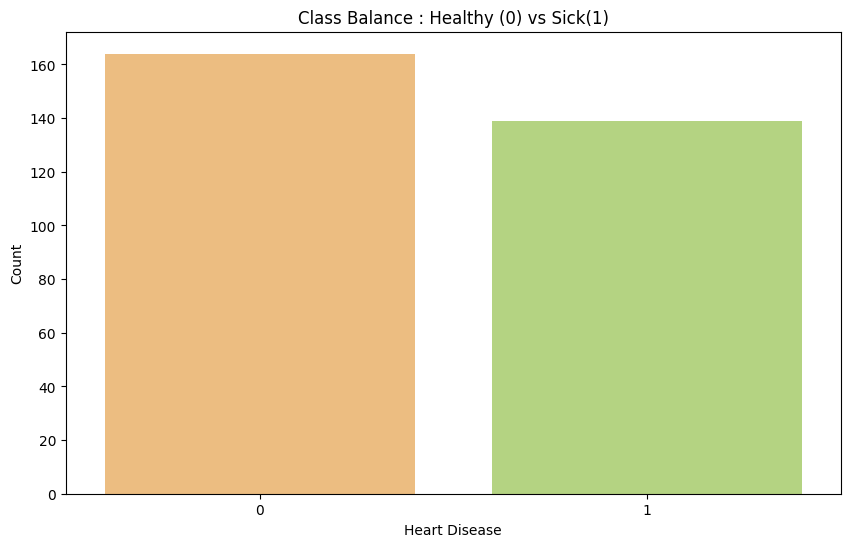

In [5]:
import seaborn as sns

import matplotlib.pyplot as plt

# Plotting

plt.figure(figsize=(10, 6))

sns.countplot(x=y.iloc[:,0],palette ='RdYlGn')

plt.title('Class Balance : Healthy (0) vs Sick(1)')

plt.xlabel('Heart Disease')

plt.ylabel('Count')

plt.show()






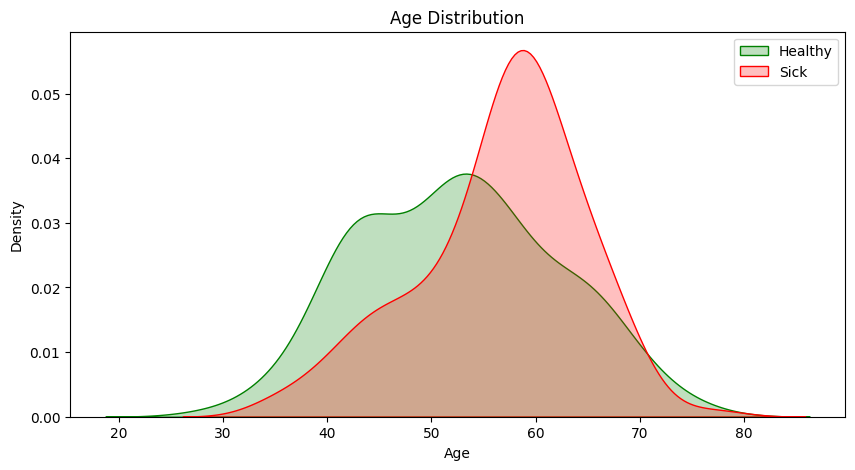

In [6]:
plt.figure(figsize=(10,5))

sns.kdeplot(X[y.iloc[:, 0] == 0]['age'],label ="Healthy",fill=True, color='green')

sns.kdeplot(X[y.iloc[:, 0] == 1]['age'],label ="Sick",fill=True, color='red')

plt.title('Age Distribution')

plt.xlabel('Age')

plt.ylabel('Density')

plt.legend()






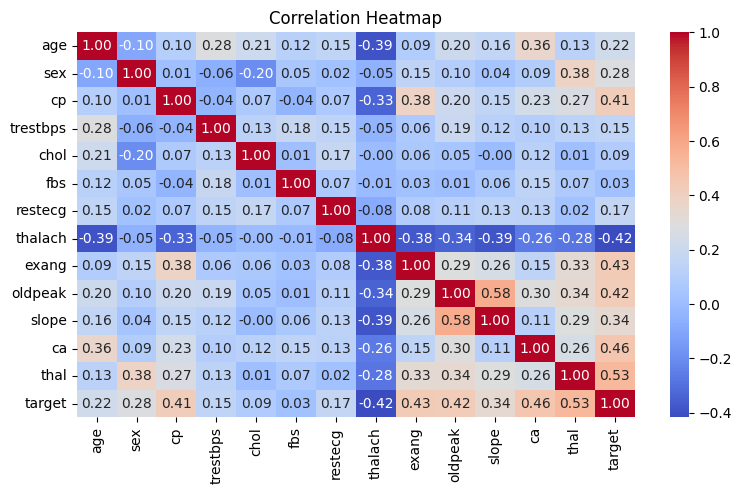

In [7]:
# Heatmap

temp_df= X.copy()

temp_df['target'] = y

plt.figure(figsize=(9,5))

sns.heatmap(temp_df.corr(),annot = True, cmap ='coolwarm', fmt = '.2f')

plt.title('Correlation Heatmap')

plt.show()






In [8]:
from sklearn.model_selection import train_test_split

X_clean  = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(X_clean,y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")

print(f"y_train shape: {y_train.shape}")

print(f"X_test shape: {X_test.shape}")

print(f"y_test shape: {y_test.shape}")






X_train shape: (242, 13)
y_train shape: (242, 1)
X_test shape: (61, 13)
y_test shape: (61, 1)


In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
model= RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Train Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")


Accuracy: 0.9016393442622951
Train Accuracy: 1.0
Test Accuracy: 0.9016393442622951


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [10]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report

# Initialize the Random Forest classifier

model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# calculate Training Accuracy

train_accuracy = model.score(X_train, y_train)

print(f"Training Accuracy: {train_accuracy}")

print(f"Testing Accuracy: {accuracy_score(y_test, y_pred)}")






/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Training Accuracy: 1.0
Testing Accuracy: 0.9016393442622951


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rclf = RandomForestClassifier(random_state=42)
rclf.fit(X_train, y_train)
y_pred = rclf.predict(X_test)
train_accurracy = rclf.score(X_train, y_train)
test_accuracy = rclf.score(X_test, y_test)
print("Train Accuracy:", train_accurracy)
print("Test Accuracy:", test_accuracy)
class_report = classification_report(y_test, y_pred)
print("Classification Report:\n", class_report)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)



/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Train Accuracy: 1.0
Test Accuracy: 0.9016393442622951
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.93      0.90        29
           1       0.93      0.88      0.90        32

    accuracy                           0.90        61
   macro avg       0.90      0.90      0.90        61
weighted avg       0.90      0.90      0.90        61

Accuracy: 0.9016393442622951
Confusion Matrix:
 [[27  2]
 [ 4 28]]


In [12]:
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import GridSearchCV, train_test_split

from sklearn.datasets import make_classification

#

X, y  = make_classification(n_samples= 1000,n_features =20, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size=0.2, random_state=42)











In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100,200],  # no.of trees
    'max_depth': [5, 10, 20],       #Limit how to deep each tree grows
    'min_samples_split': [2, 5, 10],  # min sample to split a node
    'min_samples_leaf': [1,2,4],      # min sampes required to split
    'max_features': ['sqrt', 'log2'], #features to consider consider for each split
    'bootstrap': [True, False],
    'random_state': [42],
    'max_samples': [0.5, 0.8]
}

# Initialize the Random Forest classifier
model = RandomForestClassifier()
grid_search = GridSearchCV(estimator=model,  param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits


KeyboardInterrupt: 

In [13]:
from sklearn.ensemble import RandomForestClassifier

pruned_rf = RandomForestClassifier(

    n_estimators=150,      # More trees for stable averaging

    max_depth=5,           # Even shallower trees

    min_samples_leaf=20,   # Larger leaf nodes → smoother predictions

    min_samples_split=60,  # Harder to split nodes

    max_features='sqrt',

    max_samples=0.5,       # Each tree sees only 50% of data

    bootstrap=True,

    oob_score=True,

    random_state=42

)

pruned_rf.fit(X_train, y_train)

# Scores
new_train_score = pruned_rf.score(X_train, y_train)
new_test_score = pruned_rf.score(X_test, y_test)

print(f"New Training Accuracy: {new_train_score:.4f}")
print(f"New Test Accuracy: {new_test_score:.4f}")
print(f"New Gap: {new_train_score - new_test_score:.4f}")

New Training Accuracy: 0.8850
New Test Accuracy: 0.8650
New Gap: 0.0200


In [14]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from ucimlrepo import fetch_ucirepo

# Re-fetch the dataset to ensure 'heart_disease' is defined
heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features
y = (heart_disease.data.targets > 0).astype(int)

# Handle missing values in X
X_clean = X.fillna(X.mean(numeric_only=True))


y_heart_disease_targets = (heart_disease.data.targets > 0).astype(int)
X_train_heart, X_test_heart, y_train_heart, y_test_heart = train_test_split(X_clean, y_heart_disease_targets, test_size=0.2, random_state=42)


pruned_rf = RandomForestClassifier(
    n_estimators=150,      # Large number of trees for stability
    max_depth=4,           # Very shallow trees
    min_samples_leaf=25,   # Large leaf nodes
    min_samples_split=50,  # Harder to split
    max_features='sqrt',
    max_samples=0.45,      # Trees see only 45% of data
    bootstrap=True,
    oob_score=True,
    random_state=42
)

# Fit the model using the heart disease dataset's training data (13 features)
pruned_rf.fit(X_train_heart, y_train_heart)

sample_patient = np.array([[55, 1, 1, 130, 250, 0, 1, 150, 0, 1.2, 1, 0, 2]])

# Use our 'Pruned' model to predict
prediction = pruned_rf.predict(sample_patient)
probability = pruned_rf.predict_proba(sample_patient)

print("--- CLINICAL DIAGNOSIS ---")
if prediction[0] == 1:
    print(f"Result: HIGH RISK of Heart Disease")
else:
    print(f"Result: LOW RISK / Healthy")
print(f"Confidence Level: {probability[0][prediction[0]]:.2%}")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


--- CLINICAL DIAGNOSIS ---
Result: LOW RISK / Healthy
Confidence Level: 64.76%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [15]:
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier # Import GradientBoostingClassifier

sample = np.array([[1,2,3,4,5,6,7,8,9,10,11,12,13]])

prediction = pruned_rf.predict(sample)

probability = pruned_rf.predict_proba(sample)

print(" Clininal DT")

if prediction == 1:

    print("The patient is sick")

else:

    print("The patient is healthy")

print(f"Confidence Level :{probability[0][prediction[0]]:.2%}")

# Initialize the boosted model
boosted_model = GradientBoostingClassifier(random_state=42)

boosted_model.fit(X_train, y_train)

# Check the Boosting scores

boost_train_score = boosted_model.score(X_train, y_train)

boost_test_score = boosted_model.score(X_test, y_test)

print(f"Boosting Training Accuracy: {boost_train_score:.4f}")

print(f"Boosting Test Accuracy: {boost_test_score:.4f}")

print(f"Boosting Gap: {boost_train_score - boost_test_score:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


 Clininal DT
The patient is sick
Confidence Level :58.19%
Boosting Training Accuracy: 0.9900
Boosting Test Accuracy: 0.9100
Boosting Gap: 0.0800


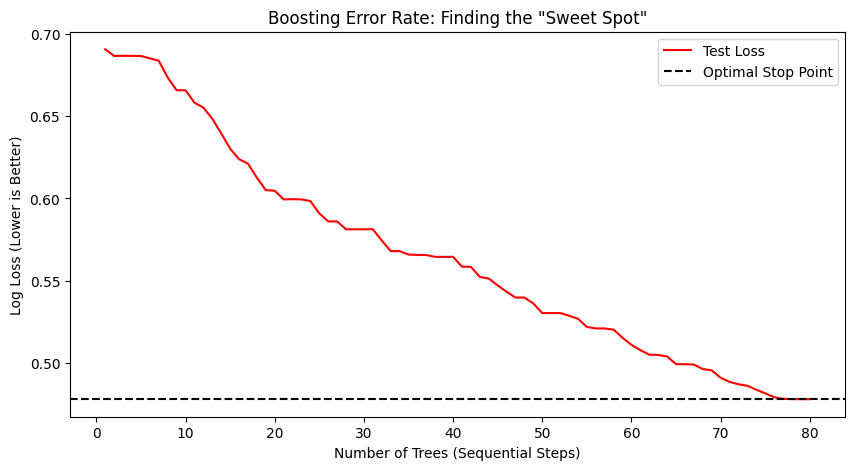

In [20]:
from sklearn.metrics import log_loss

import matplotlib.pyplot as plt

import numpy as np

# 1. Initialize an array to store the loss at each of the 300 steps

test_losses = []

# 2. staged_predict_proba gives us the "certainty" of the model at each tree

for y_proba in boosted_model.staged_predict_proba(X_test):

    test_losses.append(log_loss(y_test, y_proba))

# 3. Plot the results

plt.figure(figsize=(10, 5))

plt.plot(range(1, len(test_losses) + 1), test_losses, color='red', label='Test Loss')

plt.axhline(y=min(test_losses), color='black', linestyle='--', label='Optimal Stop Point')

plt.title('Boosting Error Rate: Finding the "Sweet Spot"')

plt.xlabel('Number of Trees (Sequential Steps)')

plt.ylabel('Log Loss (Lower is Better)')

plt.legend()

plt.show()

In [19]:
#final boosting values


from sklearn.ensemble import GradientBoostingClassifier

boosted_model = GradientBoostingClassifier(
    n_estimators=80,
    learning_rate=0.02,
    max_depth=1,
    min_samples_leaf=25,
    min_samples_split=40,
    subsample=0.5,
    max_features='sqrt',
    random_state=42
)

boosted_model.fit(X_train, y_train)

boost_train_score = boosted_model.score(X_train, y_train)
boost_test_score = boosted_model.score(X_test, y_test)

print("Boosting Training Accuracy:", round(boost_train_score,4))
print("Boosting Test Accuracy:", round(boost_test_score,4))
print("Boosting Gap:", round(boost_train_score - boost_test_score,4))

Boosting Training Accuracy: 0.865
Boosting Test Accuracy: 0.84
Boosting Gap: 0.025


In [31]:
from xgboost import XGBClassifier

from lightgbm import LGBMClassifier



# 1. XGBoost - Notice the regularization 'reg_lambda'

xgb = XGBClassifier(n_estimators=200, max_depth=3, reg_lambda=1, random_state=42)

# 2. LightGBM - Notice it's built for speed

lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.05, num_leaves=31)

lgbm.fit(X_train, y_train)
print("LightGBM Training Accuracy:", lgbm.score(X_train, y_train))
gap= lgbm.score(X_train, y_train) - lgbm.score(X_test, y_test)
print("LightGBM Test Accuracy:", lgbm.score(X_test, y_test))

# do hyperparamter tunning


lgm = LGBMClassifier(
    n_estimators=80,
    learning_rate=0.02,
    max_depth=1,
    min_samples_leaf=25,
    min_samples_split=40,
    subsample=0.5,
    max_features='sqrt',
    random_state=42
)
lgm.fit(X_train, y_train)

print("LightGBM Training Accuracy:", lgm.score(X_train, y_train))

print("LightGBM Test Accuracy:", lgm.score(X_test, y_test))


gap = lgm.score(X_train, y_train) - lgm.score(X_test, y_test)

print("LightGBM Gap:", gap)







[LightGBM] [Info] Number of positive: 393, number of negative: 407
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000341 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.491250 -> initscore=-0.035004
[LightGBM] [Info] Start training from score -0.035004
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

In [35]:
# perfrom RUC AUC curve for this
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability predictions for the positive class
y_prob = lgm.predict_proba(X_test)[:,1]


fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=25. Current value: min_data_in_leaf=25
[LightGBM] [Warning] Unknown parameter: min_samples_split
AUC Score: 0.9028238368003216


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] Unknown parameter: max_features
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=25. Current value: min_data_in_leaf=25
[LightGBM] [Warning] Unknown parameter: min_samples_split
AUC Score: 0.9028238368003216


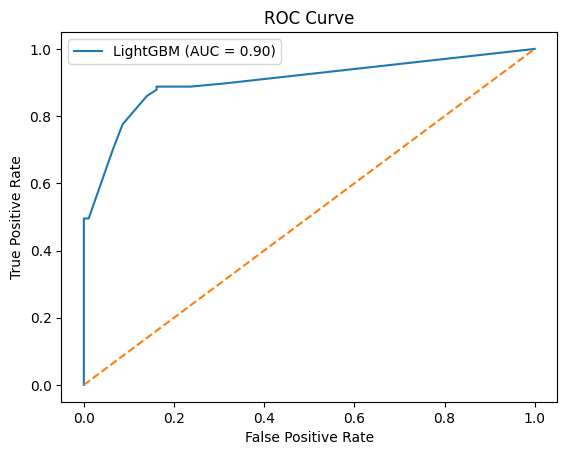

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = lgm.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

# Plot ROC Curve
plt.figure()

plt.plot(fpr, tpr, label="LightGBM (AUC = %0.2f)" % auc_score)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

0.025000000000000022
